In [1]:
pip install yfinance pandas numpy scikit-learn matplotlib pennylane -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 14.9 MB/s eta 0:00:0000:010:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 11.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.1 MB/s eta 0:00:00:00:010:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install fvcore -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
import time
from fvcore.nn import FlopCountAnalysis


/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


## Fungsi

In [4]:

def mae_mse(actual_rescaled, pred_rescaled):
    mae = mean_absolute_error(actual_rescaled, pred_rescaled)
    mse = mean_squared_error(actual_rescaled, pred_rescaled)
    rmse = np.sqrt(mse)
    
    print(f"\n=== HASIL EVALUASI (PAPER METRICS) ===")
    print(f"MAE  (Mean Absolute Error): {mae:.2f}")
    print(f"RMSE (Root Mean Sq Error): {rmse:.2f}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(actual_rescaled, label='Harga Asli (Actual)', color='blue')
    plt.plot(pred_rescaled, label='Prediksi QLSTM', color='red', linestyle='--')
    plt.title(f'Prediksi Harga Saham dengan Hybrid QLSTM (Multivariate)\nMAE: {mae:.2f}')
    plt.xlabel('Waktu (Hari ke-)')
    plt.ylabel('Harga (USD)')
    plt.legend()
    plt.show()


def directional_accuracy(y_true, y_pred):
    """
    Directional Accuracy (DA)
    Mengukur apakah arah pergerakan prediksi benar (naik/turun)

    y_true: array nilai aktual (1D)
    y_pred: array nilai prediksi (1D)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # perubahan nilai
    actual_direction = np.sign(y_true[1:] - y_true[:-1])
    pred_direction = np.sign(y_pred[1:] - y_true[:-1])

    da = np.mean(actual_direction == pred_direction)
    return da

def visual_lost(loss_hist):
    plt.figure()
    plt.plot(loss_hist)
    plt.xlabel('epoch')
    plt.ylabel('loss')


def denormalisasi(actuals, predictions):
    # ==========================================
    # 6. DENORMALISASI (Kembalikan ke Harga Asli)
    # ==========================================
    # Kita perlu trik sedikit karena scaler kita fit untuk 5 fitur,
    # tapi prediksi kita cuma 1 fitur (Close).
    
    # Buat array dummy seukuran (N, 5)
    pred_dummy = np.zeros((len(predictions), 5))
    actual_dummy = np.zeros((len(actuals), 5))
    
    # Masukkan prediksi ke kolom 'Close' (index 3 sesuai urutan awal)
    pred_dummy[:, 3] = predictions
    actual_dummy[:, 3] = actuals
    
    # Inverse Transform
    pred_rescaled = scaler.inverse_transform(pred_dummy)[:, 3]
    actual_rescaled = scaler.inverse_transform(actual_dummy)[:, 3]
    return actual_rescaled, pred_rescaled

def visual_loss_train_val(train_loss, val_loss, title='Training vs Validation Loss'):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def num_wb (model):
    weight_params = 0
    bias_params = 0
    
    for name, param in model.named_parameters():
        if "bias" in name:
            bias_params += param.numel()
        else:
            weight_params += param.numel()
    
    print("Bobot (weights):", weight_params)
    print("Bias           :", bias_params)
    print("Total          :", weight_params + bias_params)


##  Dataset

Mengunduh data BTC-USD...


/tmp/ipykernel_55/457586665.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_55/457586665.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_selected = df_selected.fillna(method='ffill')


Ukuran Data Awal: (1461, 5)
Price              Open         High          Low        Close       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7194.892090  7254.330566  7174.944336  7200.174316  18565664997
2020-01-02  7202.551270  7212.155273  6935.270020  6985.470215  20802083465
2020-01-03  6984.428711  7413.715332  6914.996094  7344.884277  28111481032
2020-01-04  7345.375488  7427.385742  7309.514160  7410.656738  18444271275
2020-01-05  7410.451660  7544.497070  7400.535645  7411.317383  19725074095

=== HASIL PREPROCESSING ===
Bentuk X_train (Sampel, Lookback, Fitur): (1160, 10, 5)
Bentuk y_train (Target): (1160,)
Bentuk X_test:  (291, 10, 5)
Bentuk y_test:  (291,)


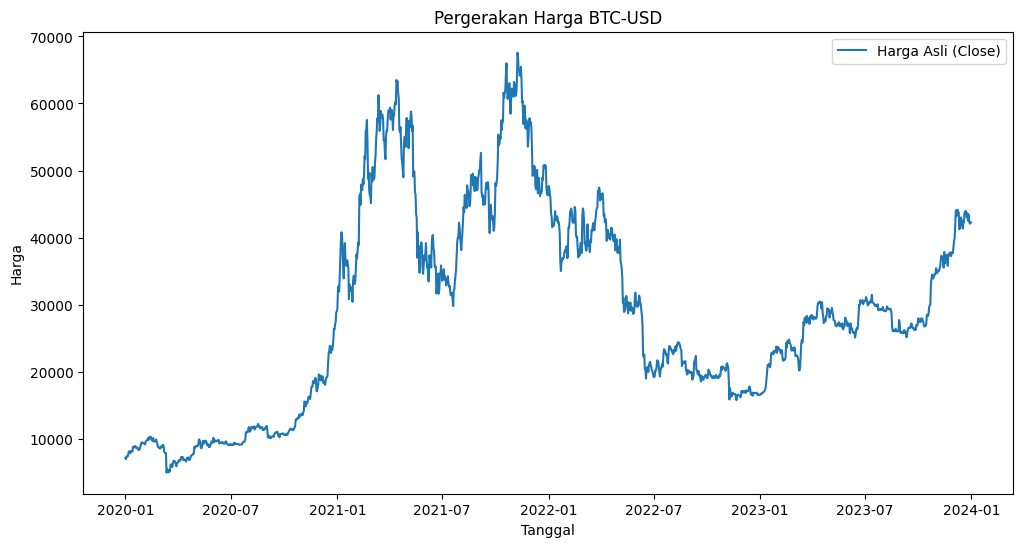

In [5]:


# ==========================================
# 1. KONFIGURASI DATASET
# ==========================================
TICKER = 'BTC-USD'  # Bisa diganti 'AAPL', 'GOOGL', dll
START_DATE = '2020-01-01'
END_DATE = '2024-01-01'
LOOKBACK = 10       # Jendela waktu (melihat 10 hari ke belakang)

print(f"Mengunduh data {TICKER}...")
# Mengambil data dari Yahoo Finance
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# ==========================================
# 2. SELEKSI FITUR (MULTIVARIATE)
# ==========================================
# Kita hanya ambil 5 kolom penting
# Pastikan urutannya konsisten
features = ['Open', 'High', 'Low', 'Close', 'Volume']
df_selected = df[features]

# Cek apakah ada data kosong (NaN) dan isi jika ada
df_selected = df_selected.fillna(method='ffill')

print(f"Ukuran Data Awal: {df_selected.shape}")
print(df_selected.head())

# ==========================================
# 3. NORMALISASI (Min-Max Scaling)
# ==========================================
# Penting untuk QML: Mengubah data menjadi rentang 0 sampai 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_selected)

# Simpan scaler ini! Nanti dibutuhkan untuk mengembalikan hasil prediksi ke harga asli.

# ==========================================
# 4. SLIDING WINDOW (Membuat Input X dan Target y)
# ==========================================
def create_sequences(data, lookback):
    X, y = [], []
    # Loop dari hari ke-n sampai data habis
    for i in range(lookback, len(data)):
        # Input (X): Ambil 5 fitur dari hari (i-lookback) sampai (i-1)
        X.append(data[i-lookback:i]) 
        
        # Target (y): Ambil hanya harga 'Close' (indeks ke-3) di hari ke-i
        # Indeks: 0=Open, 1=High, 2=Low, 3=Close, 4=Volume
        y.append(data[i, 3]) 
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, LOOKBACK)

# ==========================================
# 5. SPLITTING DATA (Train & Test)
# ==========================================
# Jangan di-shuffle (acak)! Ini data time series, urutan waktu harus dijaga.
train_size = int(len(X) * 0.8) # 80% untuk latihan

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)


# # Hitung min dan max dari data training
# X_min = X_train.min(axis=0)
# X_max = X_train.max(axis=0)

# # Hindari pembagian dengan nol
# eps = 1e-8

# # Normalisasi ke [0, pi]
# X_train = np.pi * (X_train - X_min) / (X_max - X_min + eps)
# X_test  = np.pi * (X_test  - X_min) / (X_max - X_min + eps)


print("\n=== HASIL PREPROCESSING ===")
print(f"Bentuk X_train (Sampel, Lookback, Fitur): {X_train.shape}")
print(f"Bentuk y_train (Target): {y_train.shape}")
print(f"Bentuk X_test:  {X_test.shape}")
print(f"Bentuk y_test:  {y_test.shape}")

# Visualisasi Data Target
plt.figure(figsize=(12, 6))
plt.plot(df_selected.index, df_selected['Close'], label='Harga Asli (Close)')
plt.title(f'Pergerakan Harga {TICKER}')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.show()

In [6]:
# ==========================================
# 2. PERSIAPAN DATALOADER
# ==========================================
# Ubah numpy array ke tensor PyTorch
batch_size = 16       # Ukuran batch kecil agar update bobot lebih sering

train_data = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
test_data = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float())

# Loader untuk training (Shuffle=True agar model tidak menghafal urutan batch)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
# Loader untuk testing (Shuffle=False wajib! Kita mau prediksi urut waktu)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


## QLSTM

### Circuit Quantum

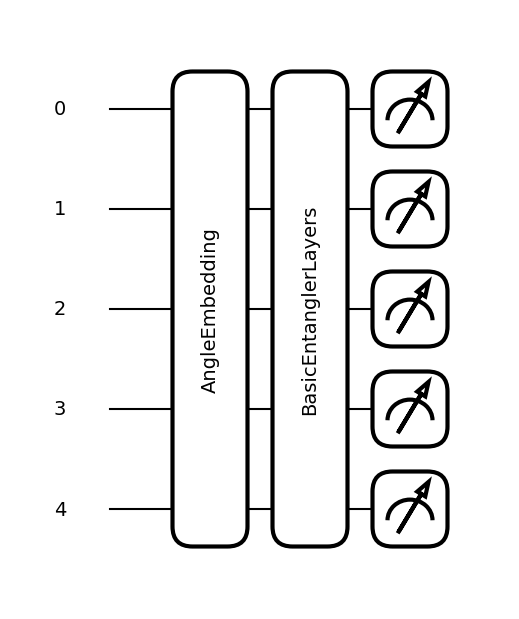

In [7]:
n_qubits = 5
dev = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev)
def qnode(inputs, weights):
    # encoding data
    qml.AngleEmbedding(inputs, wires=range(n_qubits))

    # variational layer
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))

    # measurement
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

c = np.array([0.1, 0.2, 0.3, 0.4, 0.5], requires_grad=False)
e = np.random.randn(1, n_qubits, requires_grad=True)

# ==========================================
# 4. VISUALISASI SIRKUIT (GRAFIK)
# ==========================================
fig, ax = qml.draw_mpl(qnode)(c, e)
plt.show()

In [8]:
class QLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, n_qubits, n_qlayers=1):
        super(QLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.n_qubits = n_qubits
        
        # --- 1. Persiapan Penghubung Klasik-Kuantum ---
        # Input ke gerbang LSTM adalah gabungan (concatenation) dari:
        # Input Data saat ini (xt) + Hidden State sebelumnya (ht-1)
        # Jadi ukurannya = input_size + hidden_size
        self.concat_size = input_size + hidden_size
        
        # Karena sirkuit kita fix 5 qubit, kita butuh layer klasik kecil 
        # untuk "merapikan" data gabungan tadi agar pas masuk ke 5 qubit.
        self.cl_layer_f = nn.Linear(self.concat_size, n_qubits)
        self.cl_layer_i = nn.Linear(self.concat_size, n_qubits)
        self.cl_layer_c = nn.Linear(self.concat_size, n_qubits)
        self.cl_layer_o = nn.Linear(self.concat_size, n_qubits)
        
        # --- 2. Definisi Sirkuit Kuantum (VQC) ---
        # Kita gunakan sirkuit yang sama strukturnya, tapi bobotnya nanti beda-beda
        dev = qml.device("default.qubit", wires=n_qubits)
        
        # Fungsi sirkuit (sama seperti tahap sebelumnya)
        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits))
            qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]
        
        # Bobot awal untuk sirkuit
        weight_shapes = {"weights": (n_qlayers, n_qubits)}
        
        # --- 3. Membungkus Sirkuit jadi Layer PyTorch ---
        # Kita butuh 4 VQC untuk 4 gerbang LSTM
        self.vqc_forget = qml.qnn.TorchLayer(circuit, weight_shapes)
        self.vqc_input  = qml.qnn.TorchLayer(circuit, weight_shapes)
        self.vqc_cell   = qml.qnn.TorchLayer(circuit, weight_shapes)
        self.vqc_output = qml.qnn.TorchLayer(circuit, weight_shapes)

    def forward(self, x, init_states=None):
        # x shape: (Batch, Sequence Length, Features)
        batch_size, seq_len, _ = x.size()
        
        # Inisialisasi Hidden State (h) dan Cell State (c) dengan 0
        if init_states is None:
            h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
            c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        else:
            h_t, c_t = init_states
            
        hidden_seq = []
        
        # --- LOOP TIME SERIES (Langkah per Langkah Waktu) ---
        for t in range(seq_len):
            x_t = x[:, t, :] # Ambil data pada waktu t
            
            # 1. Gabungkan Input + Hidden State Lama
            combined = torch.cat((x_t, h_t), dim=1)
            
            # 2. Hitung Gerbang (Gates) menggunakan Kuantum
            # Forget Gate
            f_in = torch.arctan(self.cl_layer_f(combined)) # arctan agar nilai masuk range sirkuit
            f_t = torch.sigmoid(self.vqc_forget(f_in))
            
            # Input Gate
            i_in = torch.arctan(self.cl_layer_i(combined))
            i_t = torch.sigmoid(self.vqc_input(i_in))
            
            # Cell Candidate
            g_in = torch.arctan(self.cl_layer_c(combined))
            g_t = torch.tanh(self.vqc_cell(g_in))
            
            # Output Gate
            o_in = torch.arctan(self.cl_layer_o(combined))
            o_t = torch.sigmoid(self.vqc_output(o_in))
            
            # 3. Update Memori LSTM (Rumus Standar LSTM)
            c_t = (f_t * c_t) + (i_t * g_t)
            h_t = o_t * torch.tanh(c_t)
            
            hidden_seq.append(h_t.unsqueeze(1))
            
        # Gabungkan hasil semua time step
        hidden_seq = torch.cat(hidden_seq, dim=1)
        return hidden_seq, (h_t, c_t)

# --- 4. MODEL UTAMA (Hybrid Model) ---
class HybridModel(nn.Module):
    def __init__(self, input_size, hidden_size, n_qubits, output_size=1):
        super(HybridModel, self).__init__()
        # Layer QLSTM
        self.qlstm = QLSTM(input_size, hidden_size, n_qubits)
        # Layer Terakhir (Klasik) untuk prediksi harga
        self.predict = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x masuk ke QLSTM
        lstm_out, _ = self.qlstm(x)
        # Kita ambil output langkah terakhir saja untuk prediksi besok
        last_hidden = lstm_out[:, -1, :]
        # Prediksi harga
        prediction = self.predict(last_hidden)
        return prediction

print("Model QLSTM berhasil didefinisikan!")

Model QLSTM berhasil didefinisikan!


Mulai Training QLSTM untuk 5 Epochs...
Mohon bersabar, simulasi kuantum sedang berjalan...
Epoch [1/5], Loss: 0.026586, Waktu: 56.7s
Epoch [2/5], Loss: 0.000795, Waktu: 113.5s
Epoch [3/5], Loss: 0.000707, Waktu: 169.9s
Epoch [4/5], Loss: 0.000551, Waktu: 226.4s
Epoch [5/5], Loss: 0.000672, Waktu: 282.7s
Training Selesai!


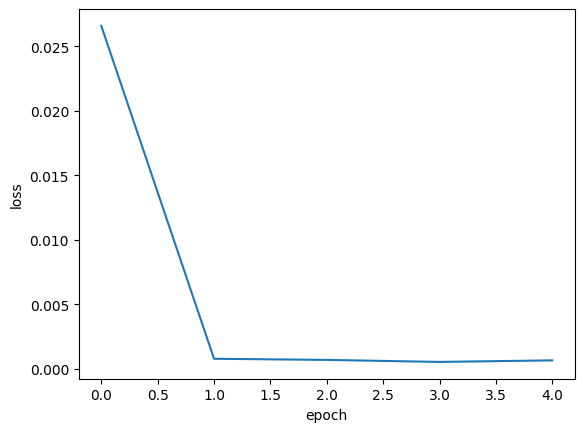

In [9]:
# ==========================================
# 1. KONFIGURASI HYPERPARAMETER
# ==========================================
# Di paper referensi, mereka melakukan grid search.
# Untuk demo ini, kita pakai angka yang umum bekerja baik.
input_size = 5      # Jumlah Fitur (Open, High, Low, Close, Volume)
hidden_size = 5     # Ukuran memori LSTM
n_qubits = 5        # Jumlah Qubit
output_size = 1     # Prediksi 1 harga (Close)

learning_rate = 0.05  # QML sering butuh LR agak tinggi di awal
num_epochs = 5        # Kita coba 5 epoch dulu agar tidak terlalu lama menunggu


# ==========================================
# 3. INISIALISASI MODEL & OPTIMIZER
# ==========================================
model_QLSTM = HybridModel(input_size, hidden_size, n_qubits, output_size)
criterion = nn.MSELoss() # Loss function MSE (sesuai paper)
optimizer = optim.Adam(model_QLSTM.parameters(), lr=learning_rate)

print(f"Mulai Training QLSTM untuk {num_epochs} Epochs...")
print("Mohon bersabar, simulasi kuantum sedang berjalan...")

# ==========================================
# 4. TRAINING LOOP
# ==========================================
history_loss = []
history_loss_val = []

start_time = time.time()

for epoch in range(num_epochs):
    model_QLSTM.train() # Set mode latihan
    epoch_loss = 0
    
    for i, (inputs, targets) in enumerate(train_loader):
        optimizer.zero_grad()            # 1. Reset gradien
        outputs = model_QLSTM(inputs)          # 2. Forward pass (Prediksi)
        loss = criterion(outputs.squeeze(), targets) # 3. Hitung error
        loss.backward()                  # 4. Backward pass (Hitung koreksi)
        optimizer.step()                 # 5. Update bobot
        
        epoch_loss += loss.item()

    
    
    # Hitung rata-rata loss per epoch
    avg_loss = epoch_loss / len(train_loader)
    history_loss.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Waktu: {time.time()-start_time:.1f}s")
visual_lost(history_loss)
print("Training Selesai!")



In [10]:
# ==========================================
# 5. EVALUASI & PREDIKSI
# ==========================================
model_QLSTM.eval() # Set mode evaluasi (matikan dropout/update bobot)
predictions = []
actuals = []

with torch.no_grad(): # Matikan perhitungan gradien agar cepat
    for inputs, targets in test_loader:
        outputs = model_QLSTM(inputs)
        predictions.extend(outputs.view(-1).cpu().numpy())
        actuals.extend(targets.view(-1).cpu().numpy())


# ==========================================
# 6. DENORMALISASI (Kembalikan ke Harga Asli)
# ==========================================
# Kita perlu trik sedikit karena scaler kita fit untuk 5 fitur,
# tapi prediksi kita cuma 1 fitur (Close).


actual_rescaled_qlstm, pred_rescaled_qlstm = denormalisasi(actuals, predictions)


Directional accuracy =  0.5310344827586206

=== HASIL EVALUASI (PAPER METRICS) ===
MAE  (Mean Absolute Error): 451.01
RMSE (Root Mean Sq Error): 670.69


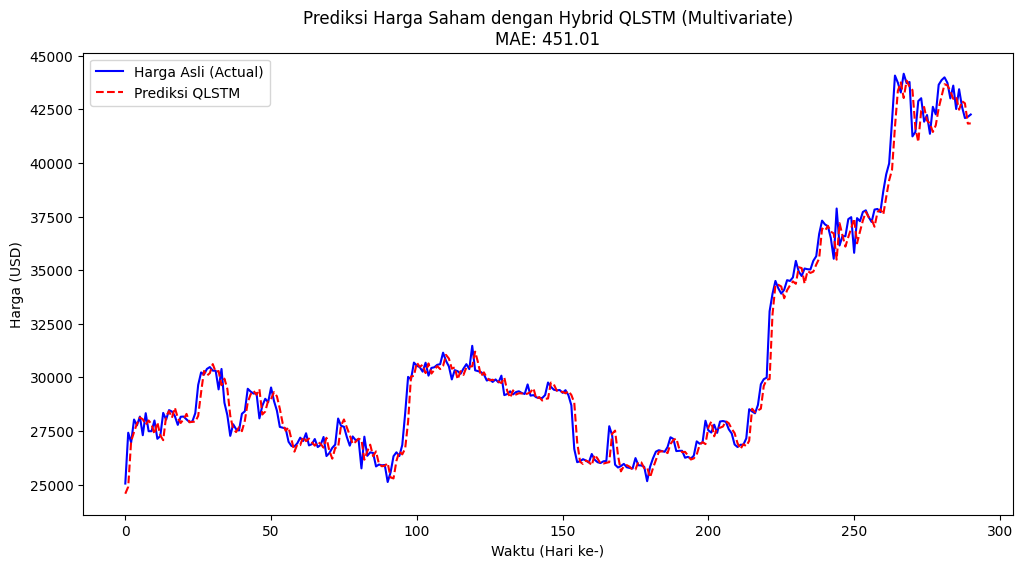

In [11]:
# ==========================================
# 7. VISUALISASI HASIL
# ==========================================
da_qlstm =  directional_accuracy(actual_rescaled_qlstm, pred_rescaled_qlstm)
print('Directional accuracy = ', da_qlstm)
mae_mse(actual_rescaled_qlstm, pred_rescaled_qlstm)

## LSTM

In [12]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, lookback, features)
        out, _ = self.lstm(x)
        
        # Ambil output timestep terakhir
        out = out[:, -1, :]
        
        out = self.fc(out)
        return out.squeeze()


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_LSTM = LSTMModel(
    input_size=5,    # Open, High, Low, Close, Volume
    hidden_size=128,
    num_layers=4
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=0.005)

print(model_LSTM)


LSTMModel(
  (lstm): LSTM(5, 128, num_layers=4, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Epoch [2/20] | Train Loss: 0.006086 | Val Loss: 0.000783
Epoch [4/20] | Train Loss: 0.002556 | Val Loss: 0.001212
Epoch [6/20] | Train Loss: 0.001392 | Val Loss: 0.000523
Epoch [8/20] | Train Loss: 0.002202 | Val Loss: 0.000299
Epoch [10/20] | Train Loss: 0.001513 | Val Loss: 0.000388
Epoch [12/20] | Train Loss: 0.000713 | Val Loss: 0.000390
Epoch [14/20] | Train Loss: 0.000687 | Val Loss: 0.000252
Epoch [16/20] | Train Loss: 0.000565 | Val Loss: 0.000183
Epoch [18/20] | Train Loss: 0.000563 | Val Loss: 0.000211
Epoch [20/20] | Train Loss: 0.000619 | Val Loss: 0.000737


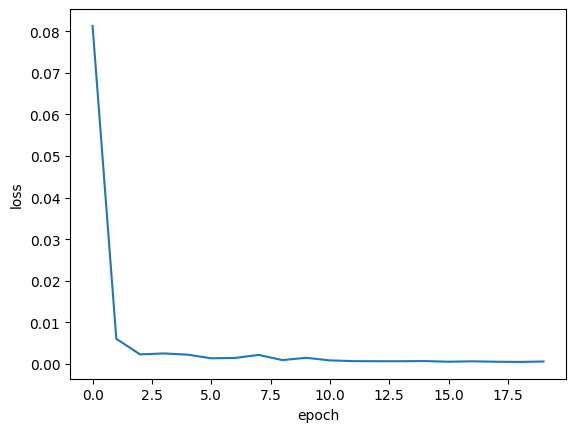

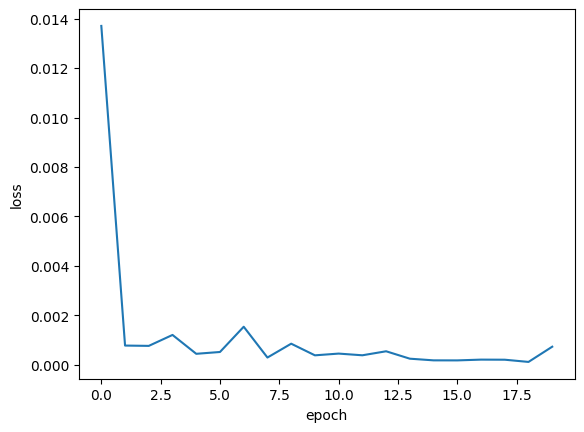

In [15]:
EPOCHS = 20
loss_hist = []
history_loss_val = []

for epoch in range(EPOCHS):
    # ==========================
    # TRAINING
    # ==========================
    model_LSTM.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_LSTM(X_batch)

        loss = criterion(outputs.view(-1), y_batch.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_hist.append(avg_loss)

    # ==========================
    # VALIDATION
    # ==========================
    model_LSTM.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model_LSTM(inputs)
            loss = criterion(outputs.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    history_loss_val.append(avg_val_loss)

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Train Loss: {avg_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f}"
        )

# ==========================
# VISUALISASI
# ==========================
visual_lost(loss_hist)
visual_lost(history_loss_val)

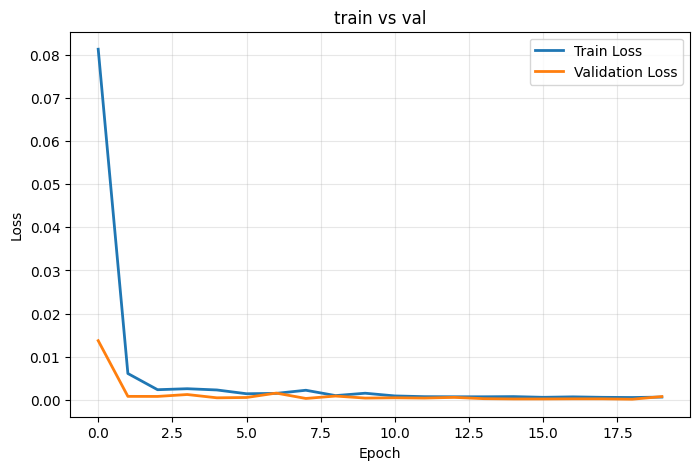

In [16]:
# ==========================
# VISUALISASI
# ==========================
# visual_lost(loss_hist)
# visual_lost(history_loss_val)

visual_loss_train_val(loss_hist, history_loss_val, 'train vs val')


Directional accuracy =  0.503448275862069

=== HASIL EVALUASI (PAPER METRICS) ===
MAE  (Mean Absolute Error): 1525.08
RMSE (Root Mean Sq Error): 1680.44


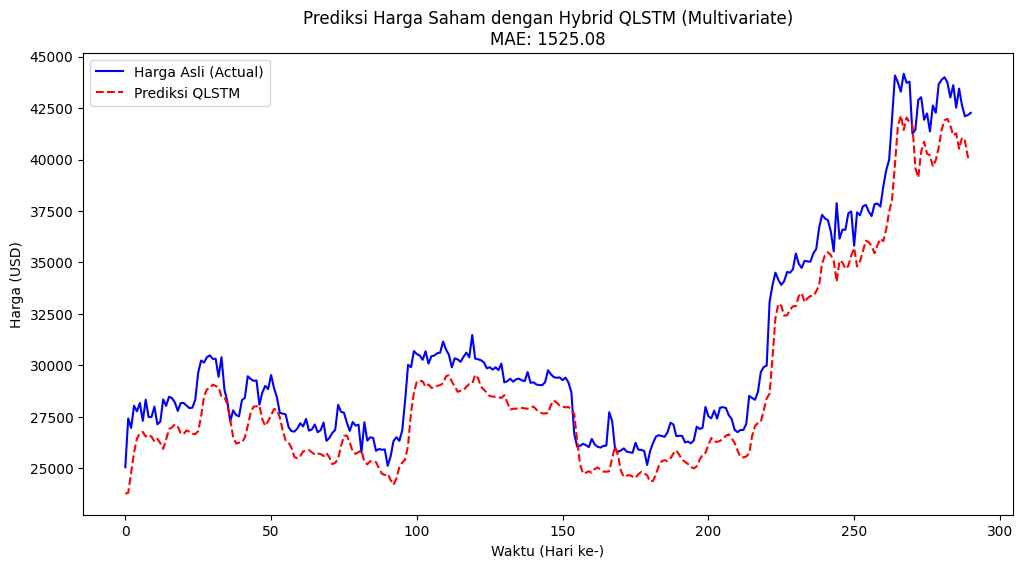

In [17]:
# ==========================================
# 5. EVALUASI & PREDIKSI
# ==========================================
model_LSTM.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        
        preds = model_LSTM(X_batch)
        
        predictions.extend(preds.squeeze().cpu().numpy().tolist())
        actuals.extend(y_batch.squeeze().cpu().numpy().tolist())

# ==========================================
# 6. DENORMALISASI (Kembalikan ke Harga Asli)
# ==========================================
# Kita perlu trik sedikit karena scaler kita fit untuk 5 fitur,
# tapi prediksi kita cuma 1 fitur (Close).
actual_rescaled_lstm, pred_rescaled_lstm = denormalisasi(actuals, predictions)

# ==========================================
# 7. VISUALISASI HASIL
# ==========================================
da_lstm =  directional_accuracy(actual_rescaled_lstm, pred_rescaled_lstm)
print('Directional accuracy = ', da_lstm)
mae_mse(actual_rescaled_lstm, pred_rescaled_lstm)

## Transformer

In [18]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


In [19]:
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):
        super().__init__()

        self.input_projection = nn.Linear(num_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: [batch, lookback, features]
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)

        # Ambil timestep terakhir
        x = x[:, -1, :]
        out = self.regressor(x)

        return out.squeeze()


In [20]:
model_T = TimeSeriesTransformer(
    num_features=X_train.shape[2],
    d_model=64,
    nhead=4,
    num_layers=2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_T.parameters(), lr=5e-4)


In [21]:
# EPOCHS = 20
# losses = []

# for epoch in range(EPOCHS):
#     model_T.train()
#     epoch_loss = 0

#     for xb, yb in train_loader:
#         optimizer.zero_grad()
#         preds = model_T(xb)
#         loss = criterion(preds, yb)
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()

#     avg_loss = epoch_loss / len(train_loader)
#     losses.append(avg_loss)

#     if (epoch+1) % 2 == 0:
#         print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.6f}")

# visual_lost(losses)

Epoch [2/6] | Train Loss: 0.057661 | Val Loss: 0.006794
Epoch [4/6] | Train Loss: 0.027338 | Val Loss: 0.001995
Epoch [6/6] | Train Loss: 0.018115 | Val Loss: 0.000882


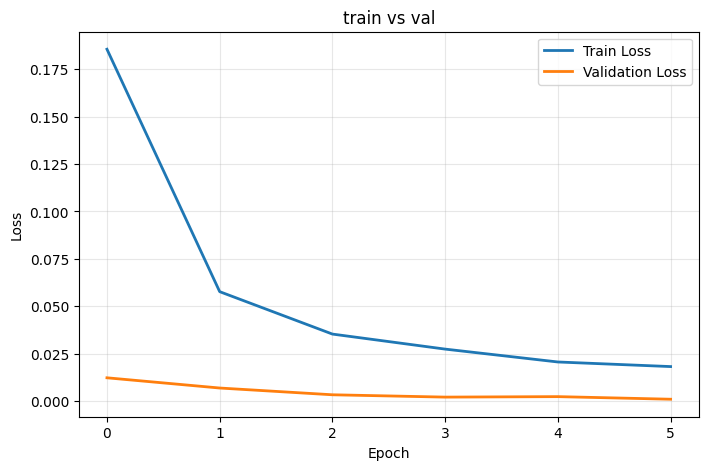

In [22]:
EPOCHS = 6
loss_hist = []
history_loss_val = []
optimizer = torch.optim.Adam(model_T.parameters(), lr=5e-6)

for epoch in range(EPOCHS):
    # ==========================
    # TRAINING
    # ==========================
    model_T.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_T(X_batch)

        loss = criterion(outputs.view(-1), y_batch.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_hist.append(avg_loss)

    # ==========================
    # VALIDATION
    # ==========================
    model_T.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model_T(inputs)
            loss = criterion(outputs.view(-1), targets.view(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    history_loss_val.append(avg_val_loss)

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch [{epoch+1}/{EPOCHS}] | "
            f"Train Loss: {avg_loss:.6f} | "
            f"Val Loss: {avg_val_loss:.6f}"
        )


# ==========================
# VISUALISASI
# ==========================
# visual_lost(loss_hist)
# visual_lost(history_loss_val)

visual_loss_train_val(loss_hist, history_loss_val, 'train vs val')


Directional accuracy =  0.5206896551724138

=== HASIL EVALUASI (PAPER METRICS) ===
MAE  (Mean Absolute Error): 1726.65
RMSE (Root Mean Sq Error): 1904.02


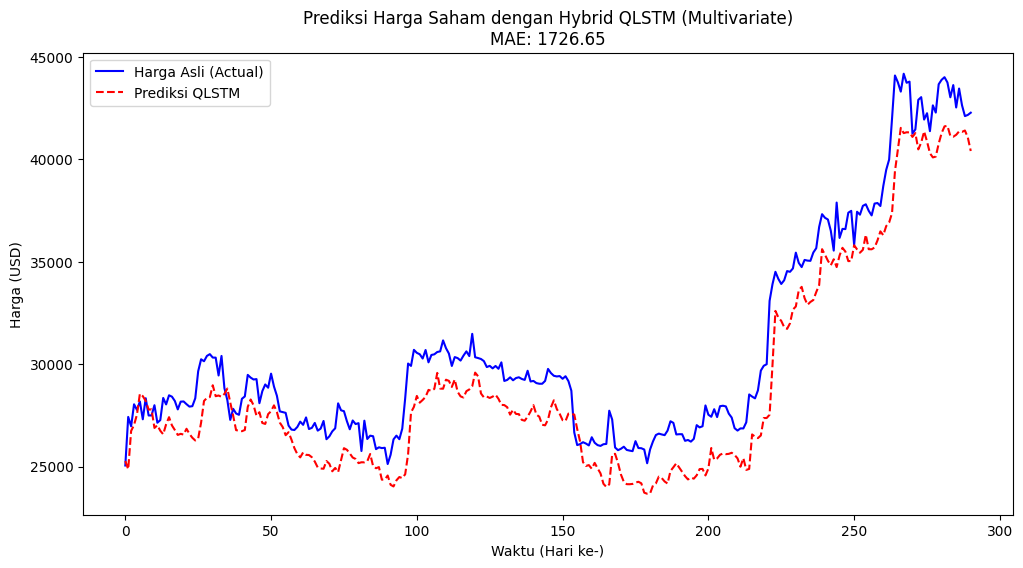

In [23]:
# ==========================================
# 5. EVALUASI & PREDIKSI
# ==========================================
model_T.eval() # Set mode evaluasi (matikan dropout/update bobot)
predictions = []
actuals = []

with torch.no_grad(): # Matikan perhitungan gradien agar cepat
    for inputs, targets in test_loader:
        Inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model_T(inputs)
        predictions.extend(outputs.squeeze().tolist())
        actuals.extend(targets.tolist())

# ==========================================
# 6. DENORMALISASI (Kembalikan ke Harga Asli)
# ==========================================
# Kita perlu trik sedikit karena scaler kita fit untuk 5 fitur,
# tapi prediksi kita cuma 1 fitur (Close).

actual_rescaled_T, pred_rescaled_T = denormalisasi(actuals, predictions)

# ==========================================
# 7. VISUALISASI HASIL
# ==========================================
da_T =  directional_accuracy(actual_rescaled_T, pred_rescaled_T)
print('Directional accuracy = ', da_T)
mae_mse(actual_rescaled_lstm, pred_rescaled_T)

In [24]:
num_wb(model_LSTM)

Bobot (weights): 461440
Bias           : 4097
Total          : 465537


In [25]:
num_wb(model_T)

Bobot (weights): 557696
Bias           : 5057
Total          : 562753


In [26]:
num_wb(model_QLSTM)

Bobot (weights): 225
Bias           : 21
Total          : 246


In [27]:
batch_size = 1
seq_len = X_train.shape[1]        # panjang window time series
num_features = X_train.shape[2]   # jumlah fitur

dummy_input = torch.randn(
    batch_size,
    seq_len,
    num_features
).to(device)
flops = FlopCountAnalysis(model_T, dummy_input)
print(f"Total FLOPs : {flops.total():,}")



Unsupported operator aten::add encountered 5 time(s)
Unsupported operator aten::div encountered 2 time(s)
Unsupported operator aten::unflatten encountered 2 time(s)
Unsupported operator aten::mul encountered 8 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 2 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
transformer_encoder.layers.0.self_attn.out_proj, transformer_encoder.layers.1.self_attn.out_proj


Total FLOPs : 5,586,624


In [28]:
batch_size = 1
seq_len = X_train.shape[1]  # window time series kamu

dummy_input = torch.randn(
    batch_size,
    seq_len,
    5
).to(device)

flops = FlopCountAnalysis(model_LSTM, dummy_input)
print(f"Total FLOPs LSTM : {flops.total():,}")

Unsupported operator aten::lstm encountered 1 time(s)


Total FLOPs LSTM : 128
